<a href="https://colab.research.google.com/github/laysmguimaraes/gest-o-de-estoque-em-ERP/blob/main/mini_erp_estoque_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Dados anteriores carregados com sucesso.

  📦 MINI-ERP: Gestão de Estoque
1. Cadastrar produto
2. Registrar Venda (Saída)
3. Registrar Compra (Entrada)
4. Excluir produto
5. Relatório Simples de Estoque
6. Relatórios Gerenciais
7. Dashboards (Gráficos)
8. Ver Histórico de Movimentações
9. Sair
------------------------------
Escolha uma opção (1-9): 7

--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 1

--- [Dashboard: Quantidade por Categoria] ---
Gerando o gráfico...

--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 2

--- [Dashboard: Análise Curva ABC] ---
Classificação ABC (Itens mais valiosos primeiro):
  

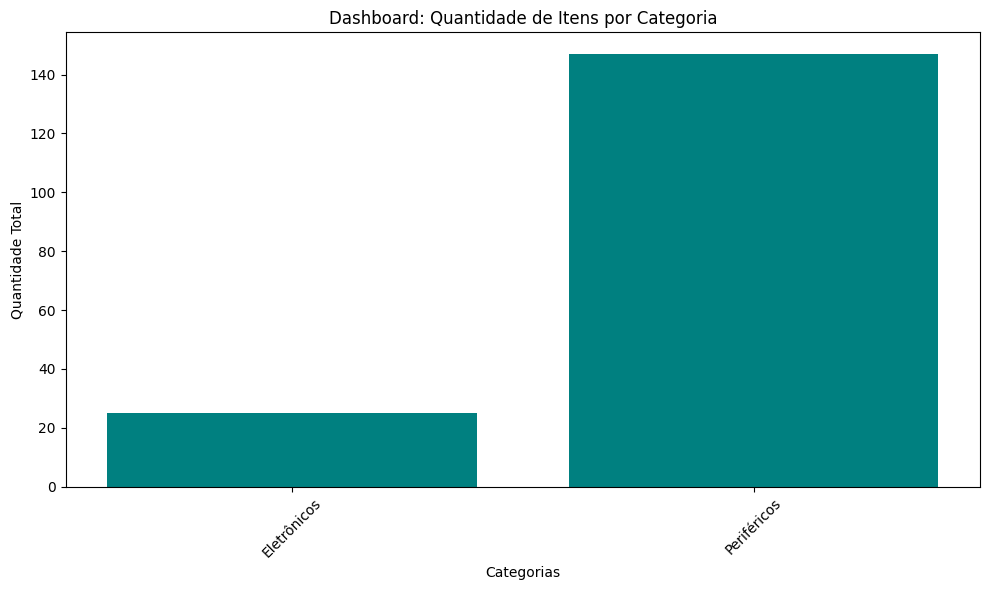

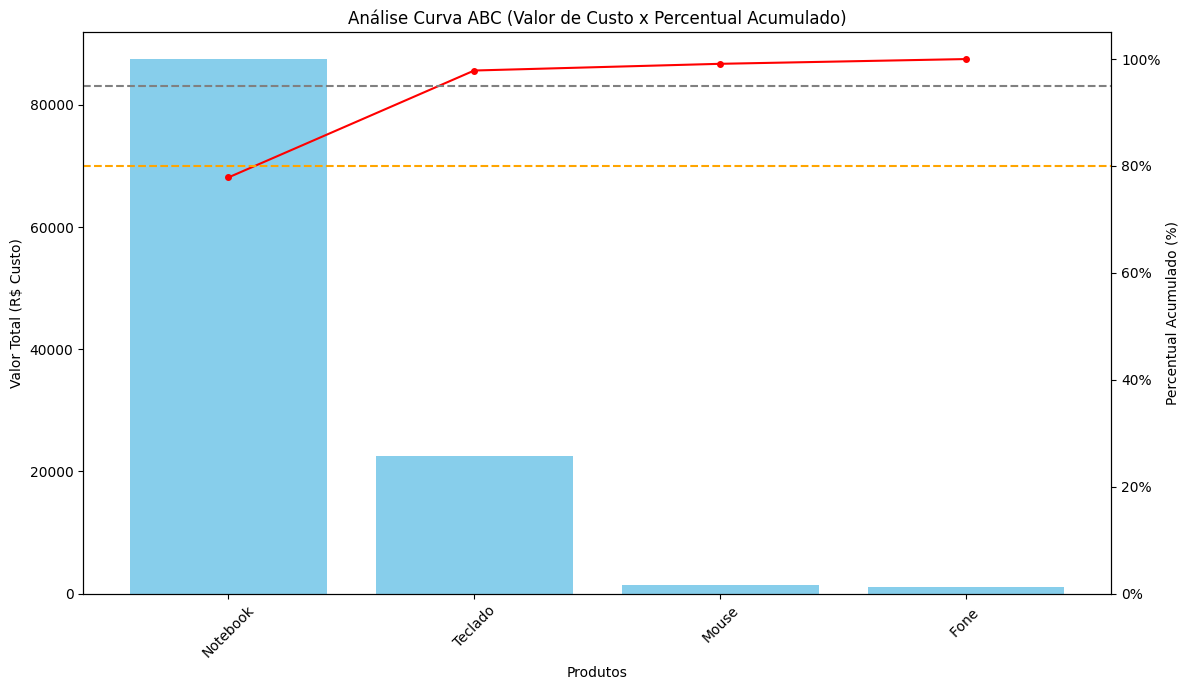


--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 3

--- [Dashboard: Evolução (Valor Estoque vs. CMV)] ---
Gerando o gráfico...


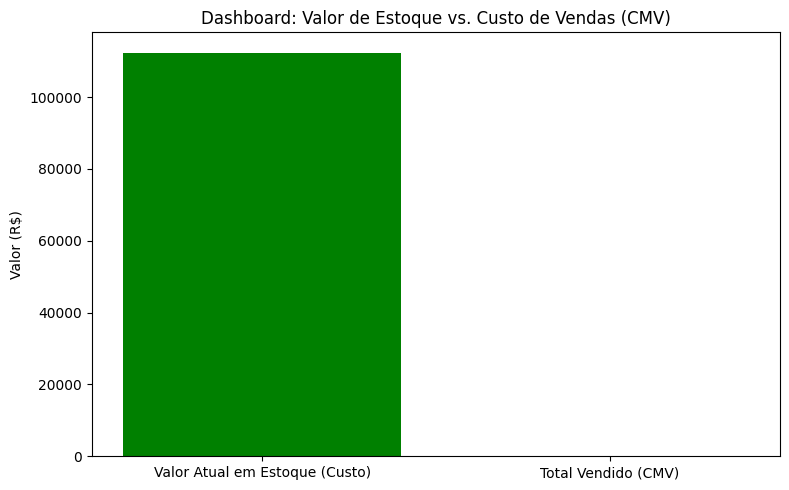


--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 3

--- [Dashboard: Evolução (Valor Estoque vs. CMV)] ---
Gerando o gráfico...


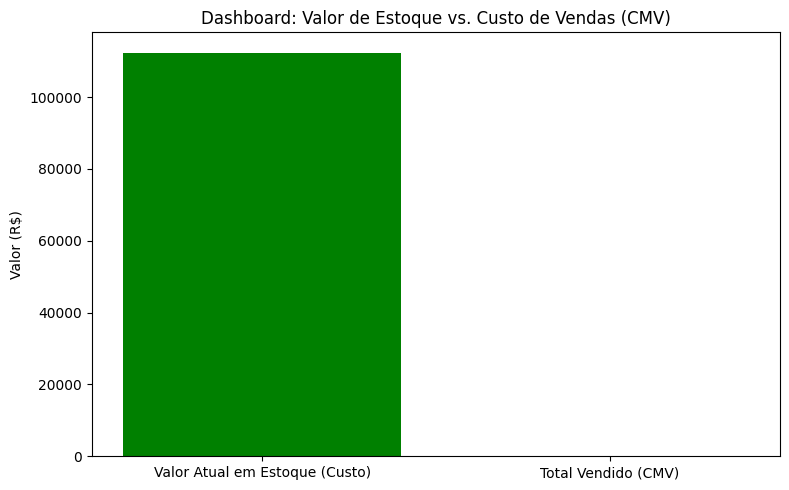


--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 4

  📦 MINI-ERP: Gestão de Estoque
1. Cadastrar produto
2. Registrar Venda (Saída)
3. Registrar Compra (Entrada)
4. Excluir produto
5. Relatório Simples de Estoque
6. Relatórios Gerenciais
7. Dashboards (Gráficos)
8. Ver Histórico de Movimentações
9. Sair
------------------------------
Escolha uma opção (1-9): 2

--- [Registrar Venda] ---
Digite o NOME ou ID do produto vendido: notebook 

[ERRO] Produto 'notebook ' não foi encontrado.

  📦 MINI-ERP: Gestão de Estoque
1. Cadastrar produto
2. Registrar Venda (Saída)
3. Registrar Compra (Entrada)
4. Excluir produto
5. Relatório Simples de Estoque
6. Relatórios Gerenciais
7. Dashboards (Gráficos)
8. Ver Histórico de Movimentações
9. Sair
------------------------------
Escolha uma opção (1-9): 4

--- [Exclu

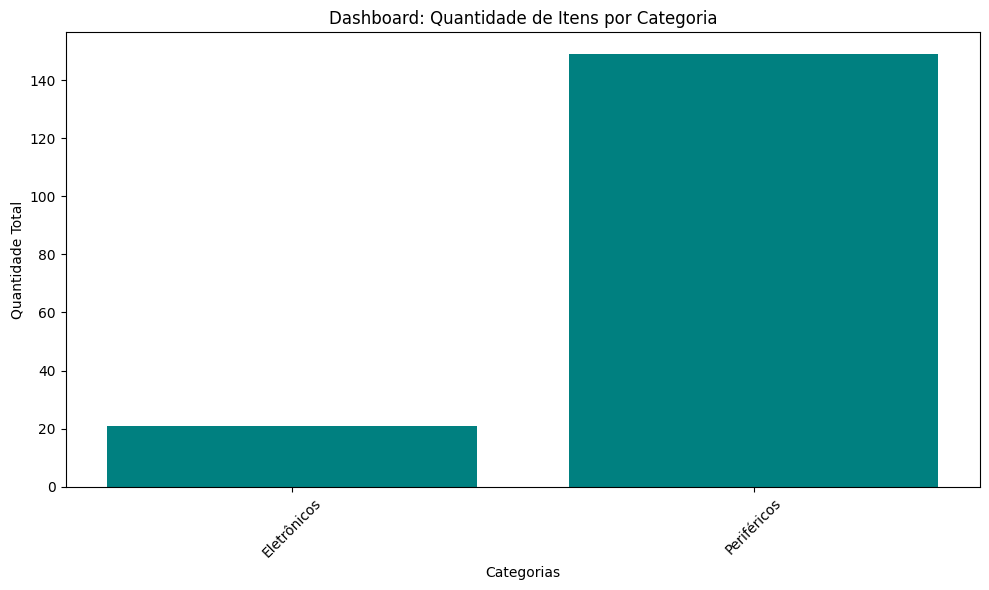

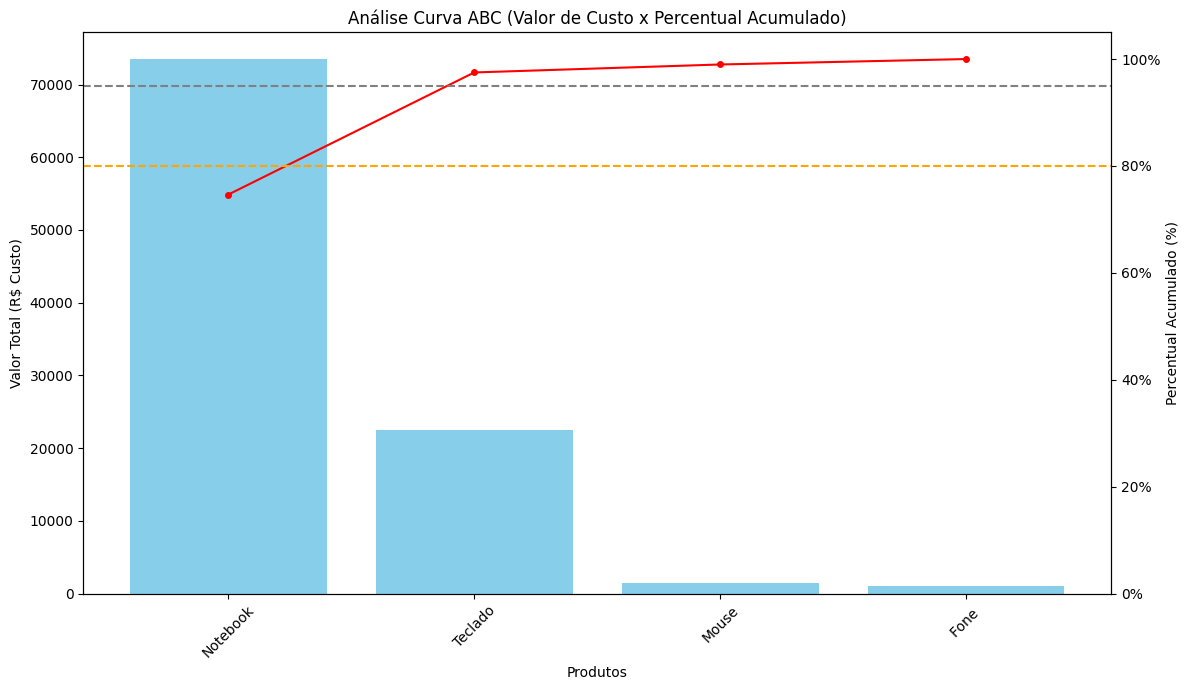


--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 3

--- [Dashboard: Evolução (Valor Estoque vs. CMV)] ---
Gerando o gráfico...


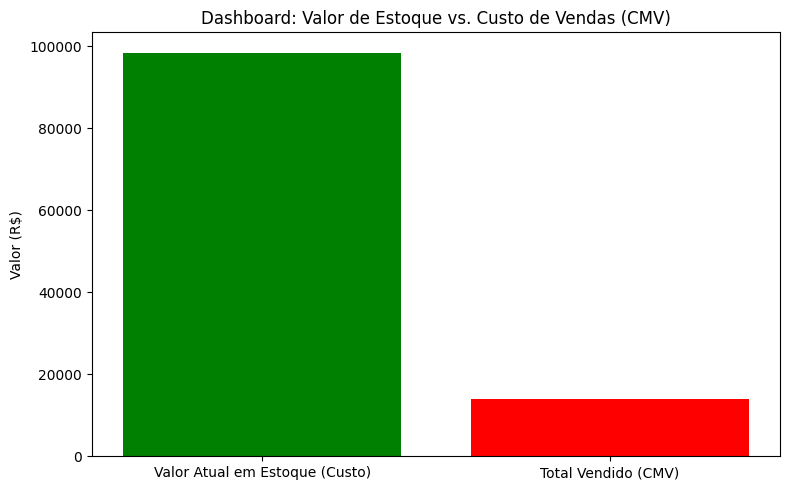


--- [Dashboard de Gráficos] ---
1. Gráfico: Quantidade por Categoria
2. Análise: Curva ABC (Valor de Custo)
3. Gráfico: Evolução (Valor Estoque vs. CMV)
4. Voltar ao Menu Principal
------------------------------
Escolha uma opção (1-4): 4

  📦 MINI-ERP: Gestão de Estoque
1. Cadastrar produto
2. Registrar Venda (Saída)
3. Registrar Compra (Entrada)
4. Excluir produto
5. Relatório Simples de Estoque
6. Relatórios Gerenciais
7. Dashboards (Gráficos)
8. Ver Histórico de Movimentações
9. Sair
------------------------------
Escolha uma opção (1-9): 8

--- [Histórico de Vendas (Saídas)] ---
  - Mouse | Qtd: 3 | CMV: R$90.00
  - Notebook | Qtd: 4 | CMV: R$14000.00

--- [Histórico de Compras (Entradas)] ---
  - Notebook | Qtd: 5
  - Mouse | Qtd: 2

  📦 MINI-ERP: Gestão de Estoque
1. Cadastrar produto
2. Registrar Venda (Saída)
3. Registrar Compra (Entrada)
4. Excluir produto
5. Relatório Simples de Estoque
6. Relatórios Gerenciais
7. Dashboards (Gráficos)
8. Ver Histórico de Movimentações
9. S

In [2]:
# --- 0. Importações ---
import json # Para salvar e carregar os dados
import os   # Para verificar se o arquivo de dados existe
import matplotlib.pyplot as plt # Para os gráficos
import matplotlib.ticker as mticker # Para formatar eixos em %

# --- 1. Estrutura de Dados ---
estoque = []
vendas = []
compras = []
proximo_id = 1
NOME_ARQUIVO = 'erp_dados.json' # Nome do nosso "banco de dados"

# --- 2. Funções de Salvar/Carregar ---

def salvar_dados():
    global estoque, vendas, compras, proximo_id

    dados = {
        'estoque': estoque,
        'vendas': vendas,
        'compras': compras,
        'proximo_id': proximo_id
    }

    try:
        with open(NOME_ARQUIVO, 'w', encoding='utf-8') as f:
            json.dump(dados, f, indent=4, ensure_ascii=False)
    except IOError as e:
        print(f"[ERRO] Falha ao salvar dados: {e}")

def carregar_dados():
    global estoque, vendas, compras, proximo_id

    if os.path.exists(NOME_ARQUIVO):
        try:
            with open(NOME_ARQUIVO, 'r', encoding='utf-8') as f:
                dados = json.load(f)

                estoque = dados.get('estoque', [])
                vendas = dados.get('vendas', [])
                compras = dados.get('compras', [])
                proximo_id = dados.get('proximo_id', 1)
            print("[INFO] Dados anteriores carregados com sucesso.")
        except json.JSONDecodeError:
            print("[AVISO] Arquivo de dados corrompido. Começando do zero.")
        except IOError as e:
            print(f"[ERRO] Falha ao carregar dados: {e}")
    else:
        print("[INFO] Nenhum arquivo de dados encontrado. Começando do zero.")


# --- 3. Funções do Sistema (CRUD) ---

def mostrar_menu():

    print("\n" + "=" * 30)
    print("  Menu Gestão de Estoque")
    print("=" * 30)
    print("1. Cadastrar produto")
    print("2. Registrar Venda (Saída)")
    print("3. Registrar Compra (Entrada)")
    print("4. Excluir produto")
    print("5. Relatório Simples de Estoque")
    print("6. Relatórios Gerenciais")
    print("7. Dashboards (Gráficos)")
    print("8. Ver Histórico de Movimentações")
    print("9. Sair")
    print("-" * 30)

def cadastrar_produto():
    global proximo_id
    print("\n--- [Cadastrar Novo Produto] ---")

    try:
        nome = input("Nome do produto: ")
        categoria = input("Categoria: ")
        preco_custo = float(input("Preço de CUSTO (ex: 9.99): "))
        preco_venda = float(input("Preço de VENDA (ex: 19.99): "))
        quantidade = int(input("Quantidade inicial: "))

        demanda_media_diaria = int(input("Demanda média diária (unidades): "))
        tempo_reposicao_dias = int(input("Tempo de reposição (dias): "))

    except ValueError:
        print("\n[ERRO] Valor inválido. O produto não foi cadastrado.")
        return

    produto = {
        "id": proximo_id,
        "nome": nome,
        "categoria": categoria,
        "preco_custo": preco_custo,
        "preco_venda": preco_venda,
        "quantidade": quantidade,
        "demanda_media_diaria": demanda_media_diaria,
        "tempo_reposicao_dias": tempo_reposicao_dias
    }

    estoque.append(produto)
    proximo_id += 1
    salvar_dados()
    print(f"\n[SUCESSO] Produto '{nome}' (ID: {produto['id']}) cadastrado.")

def encontrar_produto(identificador):
    """Função auxiliar para buscar um produto pelo nome ou ID."""
    for produto in estoque:
        if produto["nome"].lower() == identificador.lower() or str(produto["id"]) == identificador:
            return produto
    return None

def registrar_venda():
    print("\n--- [Registrar Venda] ---")
    identificador = input("Digite o NOME ou ID do produto vendido: ")
    produto = encontrar_produto(identificador)

    if not produto:
        print(f"\n[ERRO] Produto '{identificador}' não foi encontrado.")
        return

    try:
        qtd_vendida = int(input(f"Quantidade vendida de '{produto['nome']}': "))
        if qtd_vendida <= 0:
            print("[ERRO] Quantidade deve ser positiva.")
            return

        if produto['quantidade'] < qtd_vendida:
            print(f"\n[ERRO] Estoque insuficiente. (Atual: {produto['quantidade']})")
            return

        produto['quantidade'] -= qtd_vendida

        venda_registro = {
            "produto_id": produto['id'],
            "nome": produto['nome'],
            "quantidade": qtd_vendida,
            "cmv_total": produto['preco_custo'] * qtd_vendida,
            "valor_venda_total": produto['preco_venda'] * qtd_vendida
        }
        vendas.append(venda_registro)

        salvar_dados()
        print(f"\n[SUCESSO] Venda de {qtd_vendida}x '{produto['nome']}' registrada.")

    except ValueError:
        print("[ERRO] Quantidade inválida.")

def registrar_compra():
    print("\n--- [Registrar Compra] ---")
    identificador = input("Digite o NOME ou ID do produto comprado: ")
    produto = encontrar_produto(identificador)

    if not produto:
        print(f"\n[ERRO] Produto '{identificador}' não foi encontrado.")
        return

    try:
        qtd_comprada = int(input(f"Quantidade comprada de '{produto['nome']}': "))
        if qtd_comprada <= 0:
            print("[ERRO] Quantidade deve ser positiva.")
            return

        produto['quantidade'] += qtd_comprada

        compra_registro = {
            "produto_id": produto['id'],
            "nome": produto['nome'],
            "quantidade": qtd_comprada,
        }
        compras.append(compra_registro)

        salvar_dados()
        print(f"\n[SUCESSO] Compra de {qtd_comprada}x '{produto['nome']}' registrada.")

    except ValueError:
        print("[ERRO] Quantidade inválida.")

def excluir_produto():
    print("\n--- [Excluir Produto] ---")
    identificador = input("Digite o NOME ou ID do produto a excluir: ")
    produto = encontrar_produto(identificador)

    if produto:
        estoque.remove(produto)
        salvar_dados()
        print(f"\n[SUCESSO] Produto '{produto['nome']}' foi removido.")
    else:
        print(f"\n[ERRO] Produto '{identificador}' não foi encontrado.")

# --- 4. Funções de Relatório ---

def mostrar_relatorio_simples():
    print("\n--- [Relatório Simples de Estoque] ---")

    if not estoque:
        print("O estoque está vazio.")
        return

    print(f"{'ID':<4} | {'Nome':<20} | {'Qtd':<5} | {'Custo (R$)':<10} | {'Venda (R$)':<10}")
    print("-" * 55)

    for produto in estoque:
        print(f"{produto['id']:<4} | {produto['nome']:<20} | {produto['quantidade']:<5} | {produto['preco_custo']:<10.2f} | {produto['preco_venda']:<10.2f}")

        if produto['quantidade'] < 5:
            print("    -> ALERTA: Estoque baixo!")

    print("-" * 55)

def mostrar_relatorios_gerenciais():
    print("\n--- [Relatórios Gerenciais] ---")

    if not vendas:
        print("Nenhuma venda registrada. Não é possível calcular o Giro de Estoque.")
        return

    # 1. Custo da Mercadoria Vendida (CMV) Total
    cmv_total = sum(v['cmv_total'] for v in vendas)
    print(f"Custo Total das Mercadorias Vendidas (CMV): R$ {cmv_total:.2f}")

    # 2. Valor Total do Estoque Atual (baseado no custo)
    valor_total_estoque = sum(p['preco_custo'] * p['quantidade'] for p in estoque)
    print(f"Valor Total do Estoque Atual (a preço de custo): R$ {valor_total_estoque:.2f}")

    # 3. Giro de Estoque
    if valor_total_estoque > 0:
        giro_estoque = cmv_total / valor_total_estoque
        print(f"Giro de Estoque (CMV / Valor Estoque): {giro_estoque:.2f}")
    else:
        print("Giro de Estoque: N/A (Estoque zerado)")

    print("-" * 30)
    print("--- Estoque de Segurança (por produto) ---")

    if not estoque:
        print("Nenhum produto cadastrado.")
        return

    # 4. Estoque de Segurança (calculado por produto)
    for p in estoque:
        seguranca = p['demanda_media_diaria'] * p['tempo_reposicao_dias']
        print(f"  - {p['nome']:<20} | Estoque de Segurança: {seguranca} unidades")

        if p['quantidade'] < seguranca:
            print(f"    -> ALERTA! Estoque atual ({p['quantidade']}) abaixo da segurança!")

def ver_historico_movimentacoes():
  print("\n--- [Histórico de Vendas (Saídas)] ---")
    if not vendas:
        print("Nenhuma venda registrada.")
    else:
        for v in vendas:
            print(f"  - {v['nome']} | Qtd: {v['quantidade']} | CMV: R${v['cmv_total']:.2f}")

    print("\n--- [Histórico de Compras (Entradas)] ---")
    if not compras:
        print("Nenhuma compra registrada.")
    else:
        for c in compras:
            print(f"  - {c['nome']} | Qtd: {c['quantidade']}")

# --- 5. Funções de Gráficos (Dashboard) ---

def mostrar_grafico_categorias():
    print("\n--- [Dashboard: Quantidade por Categoria] ---")

    if not estoque:
        print("O estoque está vazio.")
        return

    categorias = {} # Dicionário para agrupar
    for produto in estoque:
        cat = produto['categoria']
        if cat not in categorias:
            categorias[cat] = 0
        categorias[cat] += produto['quantidade']

    if not categorias:
        print("Nenhuma categoria encontrada.")
        return

    nomes_cat = list(categorias.keys())
    qtdes_cat = list(categorias.values())

    try:
        plt.figure(figsize=(10, 6))
        plt.bar(nomes_cat, qtdes_cat, color='teal')
        plt.title('Dashboard: Quantidade de Itens por Categoria')
        plt.xlabel('Categorias')
        plt.ylabel('Quantidade Total')
        plt.xticks(rotation=45)
        plt.tight_layout()
        print("Gerando o gráfico...")

        plt.show()

    except Exception as e:
        print(f"\n[ERRO] Não foi possível gerar o gráfico: {e}")

def mostrar_curva_abc():
    print("\n--- [Dashboard: Análise Curva ABC] ---")

    if not estoque:
        print("O estoque está vazio.")
        return

    # 1. Calcular o valor total de CUSTO de cada produto
    produtos_com_valor = []
    valor_total_global = 0
    for p in estoque:
        valor_item = p['preco_custo'] * p['quantidade']
        if valor_item > 0:
            produtos_com_valor.append({'nome': p['nome'], 'valor': valor_item})
            valor_total_global += valor_item

    if valor_total_global == 0:
        print("O valor total do estoque é zero. Não é possível gerar a Curva ABC.")
        return

    # 2. Ordenar produtos por valor (do maior para o menor)
    produtos_com_valor.sort(key=lambda x: x['valor'], reverse=True)

    # 3. Calcular percentual acumulado
    nomes_ordenados = []
    valores_ordenados = []
    percentual_acumulado_lista = []

    valor_acumulado = 0
    print("Classificação ABC (Itens mais valiosos primeiro):")

    for item in produtos_com_valor:
        nomes_ordenados.append(item['nome'])
        valores_ordenados.append(item['valor'])

        valor_acumulado += item['valor']
        percentual_acumulado = (valor_acumulado / valor_total_global) * 100
        percentual_acumulado_lista.append(percentual_acumulado)

        # 4. Classificar e imprimir
        classe = ''
        if percentual_acumulado <= 80:
            classe = 'A'
        elif percentual_acumulado <= 95: # (80% + 15%)
            classe = 'B'
        else:
            classe = 'C'
        print(f"  - {item['nome']:<20} | Valor (Custo): R${item['valor']:<10.2f} | Classe: {classe}")

    # 5. Gerar o Gráfico de Pareto (ABC)
    try:
        fig, ax1 = plt.subplots(figsize=(12, 7))

        ax1.bar(nomes_ordenados, valores_ordenados, color='skyblue')
        ax1.set_xlabel('Produtos')
        ax1.set_ylabel('Valor Total (R$ Custo)')
        ax1.tick_params(axis='x', rotation=45)

        ax2 = ax1.twinx() # Segundo eixo Y
        ax2.plot(nomes_ordenados, percentual_acumulado_lista, color='red', marker='o', ms=4)
        ax2.set_ylabel('Percentual Acumulado (%)')
        ax2.yaxis.set_major_formatter(mticker.PercentFormatter()) # Formata como %
        ax2.set_ylim([0, 105])

        ax2.axhline(y=80, color='orange', linestyle='--', label='Classe A (80%)')
        ax2.axhline(y=95, color='gray', linestyle='--', label='Classe B (95%)')

        plt.title('Análise Curva ABC (Valor de Custo x Percentual Acumulado)')
        fig.tight_layout()
        print("\nGerando o gráfico...")

       plt.show()

    except Exception as e:
        print(f"\n[ERRO] Não foi possível gerar o gráfico: {e}")

def mostrar_grafico_evolucao_estoque():
    print("\n--- [Dashboard: Evolução (Valor Estoque vs. CMV)] ---")

    if not estoque and not vendas:
        print("Nenhum dado para mostrar.")
        return

    # 1. Custo da Mercadoria Vendida (CMV) Total
    cmv_total = sum(v['cmv_total'] for v in vendas)

    # 2. Valor Total do Estoque Atual (baseado no custo)
    valor_total_estoque = sum(p['preco_custo'] * p['quantidade'] for p in estoque)

    valores = [valor_total_estoque, cmv_total]
    nomes = ['Valor Atual em Estoque (Custo)', 'Total Vendido (CMV)']

    try:
        plt.figure(figsize=(8, 5))
        plt.bar(nomes, valores, color=['green', 'red'])
        plt.title('Dashboard: Valor de Estoque vs. Custo de Vendas (CMV)')
        plt.ylabel('Valor (R$)')
        plt.tight_layout()
        print("Gerando o gráfico...")

        plt.show()

    except Exception as e:
        print(f"\n[ERRO] Não foi possível gerar o gráfico: {e}")


def menu_graficos():
    """Sub-menu para os diferentes gráficos."""
    while True:
        print("\n--- [Dashboard de Gráficos] ---")
        print("1. Gráfico: Quantidade por Categoria")
        print("2. Análise: Curva ABC (Valor de Custo)")
        print("3. Gráfico: Evolução (Valor Estoque vs. CMV)")
        print("4. Voltar ao Menu Principal")
        print("-" * 30)

        opcao = input("Escolha uma opção (1-4): ")

        if opcao == '1':
            mostrar_grafico_categorias()
        elif opcao == '2':
            mostrar_curva_abc()
        elif opcao == '3':
            mostrar_grafico_evolucao_estoque()
        elif opcao == '4':
            break # Volta ao menu principal
        else:
            print("\n[ERRO] Opção inválida.")


# --- 6. Loop Principal do Programa ---
def main():

    carregar_dados()

    while True:
        mostrar_menu()
        opcao = input("Escolha uma opção (1-9): ")

        if opcao == '1':
            cadastrar_produto()
        elif opcao == '2':
            registrar_venda()
        elif opcao == '3':
            registrar_compra()
        elif opcao == '4':
            excluir_produto()
        elif opcao == '5':
            mostrar_relatorio_simples()
        elif opcao == '6':
            mostrar_relatorios_gerenciais()
        elif opcao == '7':
            menu_graficos() # Chama o novo sub-menu
        elif opcao == '8':
            ver_historico_movimentacoes()
        elif opcao == '9':
            print("\nSaindo do Mini-ERP... Até logo!")
            break
        else:
            print("\n[ERRO] Opção inválida.")

# Executa a função principal
if __name__ == "__main__":
    main()